# Creative Health & Explainability Dashboard

**Smadex hackathon prototype:** survival risk, survival curves, and SHAP-style explanations aligned with `survival_fatigue_rsf_shap.py`.

### Features used (correct setup)

- **`creative_merged.csv`:** static creative fields (format, theme, scores, flags, copy fields — no lifetime KPIs as inputs).
- **`creative_daily_country_os_stats.csv`:** first-week delivery totals (sum over country×OS), with `days_since_launch` capped **before `fatigue_day`** for fatigued creatives (same logic as the Python module).
- **Outcome:** time-to-fatigue vs censoring at last observed day in daily data.

Optional: if you already ran the batch pipeline, `fatigue_scores_all_creatives.csv` is merged in for **P(fatigue by day 30)** in the header.

## 1. Setup & imports

In [2]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [3]:
import sys
from pathlib import Path

sys.modules['bottleneck'] = None
sys.modules['numexpr'] = None

import warnings

warnings.filterwarnings('ignore')

import IPython.display as ipd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import shap
from IPython.display import clear_output, display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sksurv.util import Surv

# Repo root = parent of notebooks/
DS_ROOT = Path('..').resolve()
if str(DS_ROOT) not in sys.path:
    sys.path.insert(0, str(DS_ROOT))

import survival_fatigue_rsf_shap as sf

pd.set_option('display.max_columns', 60)
np.random.seed(42)

SCORES_CSV = DS_ROOT / "outputs" / "survival_fatigue_rsf" / "static_plus_first_week" / "fatigue_scores_all_creatives.csv"

print("Imports OK. DS_ROOT =", DS_ROOT)

Imports OK. DS_ROOT = /Users/joelsanfeliu/Downloads/HACK_UPC_SMADEX/data_science


## 2. Load data & build **static + first week** feature matrix

Uses `sf.build_survival_table`, `sf.build_early_daily_features`, `sf.build_feature_matrix` (variant `static_plus_first_week`).

In [4]:
merged = pd.read_csv(sf.MERGED_PATH)
daily = pd.read_csv(
    sf.DAILY_PATH,
    usecols=["creative_id", "days_since_launch", *sf.DAILY_NUMERIC],
)

surv = sf.build_survival_table(merged, daily)
early = sf.build_early_daily_features(daily, merged, use_first_week=True)
X, feature_cols = sf.build_feature_matrix(surv, early, "static_plus_first_week")

cat_cols = [c for c in feature_cols if X[c].dtype == object or str(X[c].dtype) == "string"]
num_cols = [c for c in feature_cols if c not in cat_cols]
y = Surv.from_arrays(event=surv["event"].values, time=surv["duration"].values)

idx_train, idx_test = train_test_split(
    np.arange(len(surv)),
    test_size=0.25,
    random_state=sf.RANDOM_STATE,
    stratify=surv["event"].values,
)

X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

pipe: Pipeline = sf.make_pipeline(cat_cols, num_cols)
pipe.fit(X_train, y_train)

scores_df = None
if SCORES_CSV.exists():
    scores_df = pd.read_csv(SCORES_CSV)
    scores_df = scores_df[scores_df["model_variant"] == "static_plus_first_week"]

print(f"Creatives: {len(surv)} | Features: {len(feature_cols)}")
print("Categorical:", len(cat_cols), "| Numeric:", len(num_cols))
print("Train:", len(X_train), "| Test:", len(X_test))

Creatives: 1080 | Features: 35
Categorical: 10 | Numeric: 25
Train: 810 | Test: 270


## 3. Global SHAP (surrogate on RSF risk)

`TreeExplainer` does not support `RandomSurvivalForest`. We fit a **RandomForestRegressor** on **transformed** training rows to predict **RSF risk**, then explain that surrogate (standard hackathon pattern).

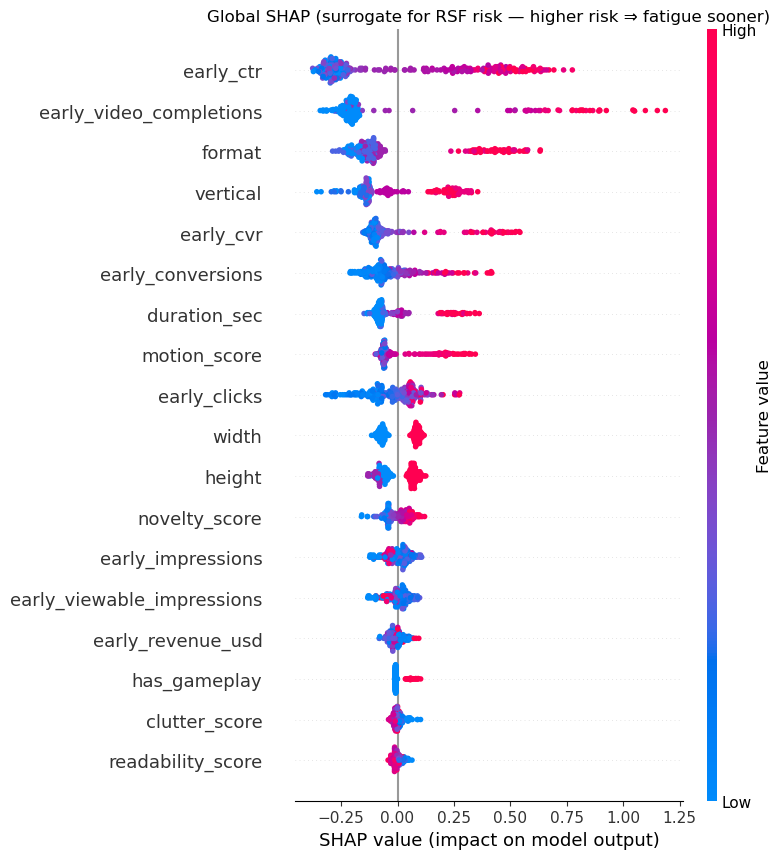

SHAP ready for dashboard waterplots.


In [5]:
Xt_train = sf.transform_X(pipe, X_train)
Xt_test = sf.transform_X(pipe, X_test)

rsf = pipe.named_steps["rsf"]
risk_train = rsf.predict(Xt_train.values)
risk_test = rsf.predict(Xt_test.values)

surrogate = RandomForestRegressor(
    n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=sf.RANDOM_STATE
)
surrogate.fit(Xt_train.values, risk_train)

explainer = shap.TreeExplainer(surrogate)
shap_obj = explainer(Xt_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_obj.values, Xt_test, show=False, max_display=18)
plt.title("Global SHAP (surrogate for RSF risk — higher risk ⇒ fatigue sooner)")
plt.tight_layout()
plt.show()

print("SHAP ready for dashboard waterplots.")

## 4. Interactive creative health view

Pick a **test-set** creative: predicted survival **S(t)**, **health score** (percentile of risk vs train), optional **P(fatigue by day 30)** from batch CSV, and **local SHAP** (surrogate).

In [ ]:
test_creative_ids = surv.iloc[idx_test]["creative_id"].astype(int).values
dropdown = widgets.Dropdown(
    options=sorted(test_creative_ids),
    description="creative_id:",
    style={"description_width": "initial"},
)
out = widgets.Output()


def plot_health_dashboard(creative_id: int) -> None:
    with out:
        clear_output(wait=True)
        mask = surv.iloc[idx_test]["creative_id"].values == creative_id
        if not mask.any():
            print("Pick a creative from the test split (dropdown list).")
            return
        pos = int(np.argmax(mask))
        orig_idx = int(idx_test[pos])
        row = surv.iloc[orig_idx]
        x_row = X_test.iloc[[pos]]
        Xt_row = sf.transform_X(pipe, x_row)

        surv_fn = rsf.predict_survival_function(Xt_row.values)[0]
        times = np.asarray(surv_fn.x)
        probs = surv_fn(times)

        risk_score = float(rsf.predict(Xt_row.values)[0])
        risk_percentile = float(stats.percentileofscore(risk_train, risk_score))
        health_score = 100.0 - risk_percentile
        health_color = "#27AE60" if health_score >= 60 else ("#F39C12" if health_score >= 30 else "#E74C3C")

        p30 = None
        if scores_df is not None:
            m = scores_df.loc[scores_df["creative_id"] == creative_id]
            if len(m):
                p30 = float(m.iloc[0].get("p_fatigue_by_day_30", np.nan))

        p30_html = f"<b>P(fatigue by day 30):</b> {p30:.3f}" if p30 is not None and np.isfinite(p30) else ""

        display(
            ipd.HTML(
                f"""
        <div style="background-color:#2C3E50; padding:15px; border-radius:10px; color:white; font-family:sans-serif;">
            <h2 style="margin:0; color:#F1C40F;">Creative {creative_id}</h2>
            <p><b>Status:</b> {row['creative_status']} | <b>Time / censor (days):</b> {int(row['duration'])}
            | <b>Format:</b> {row.get('format','')} | <b>Vertical:</b> {row.get('vertical','')}</p>
            <p>{p30_html}</p>
            <p style="font-size:0.9em;">Features = static merged fields + first-week daily (pre-fatigue cap). Not causal.</p>
        </div>
        """
            )
        )

        fig = plt.figure(figsize=(14, 10))

        ax1 = plt.subplot(2, 2, 1)
        ax1.step(times, probs, where="post", color="#2980B9", lw=2.5)
        if row["creative_status"] == "fatigued" and pd.notna(row.get("fatigue_day")):
            fd = float(row["fatigue_day"])
            ax1.axvline(fd, color="red", ls="--", lw=2, label=f"Observed fatigue_day ≈ {fd:.0f}")
        ax1.set_ylim(0, 1.05)
        ax1.set_title("Predicted S(t) — P(T > t)", fontweight="bold")
        ax1.set_xlabel("Days since launch")
        ax1.set_ylabel("Survival probability")
        ax1.grid(alpha=0.3)
        ax1.legend()

        ax2 = plt.subplot(2, 2, 2)
        ax2.hist(risk_train, bins=35, color="#BDC3C7", alpha=0.75, density=True)
        ax2.axvline(risk_score, color=health_color, lw=3, label=f"This creative risk = {risk_score:.3f}")
        ax2.set_title(f"Health score (risk percentile) ≈ {health_score:.0f}/100", fontweight="bold", color=health_color)
        ax2.set_xlabel("RSF risk on train distribution")
        ax2.set_ylabel("Density")
        ax2.grid(alpha=0.3)
        ax2.legend()

        ax3 = plt.subplot(2, 1, 2)
        ax3.set_title(f"Local SHAP (surrogate) — risk ≈ {risk_score:.3f}", fontweight="bold")
        plt.sca(ax3)
        try:
            shap.waterfall_plot(shap_obj[pos], max_display=12, show=False)
        except Exception as e:
            ax3.text(0.1, 0.5, f"Waterfall unavailable: {e}", transform=ax3.transAxes)
        plt.tight_layout()
        plt.show()


def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        plot_health_dashboard(int(change["new"]))


dropdown.observe(on_change)
display(dropdown)
display(out)
plot_health_dashboard(int(dropdown.value))

Dropdown(description='creative_id:', options=(np.int64(500003), np.int64(500006), np.int64(500015), np.int64(5…

Output()